In [ ]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack, csr_matrix
import re
import warnings

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [ ]:
DATA_PATH = "/content/data/independent-medical-review-imr-determinations-trends.csv"
OUTPUT_DIR = "outputs" # Directory to save results
MAX_TFIDF_FEATURES = 500    # Number of TF-IDF features

In [ ]:
def load_and_clean_data(filepath: str) -> pd.DataFrame:
    """
    Load the IMR CSV and prepare it for modeling

    Reads the CSV, creates a binary target variable from the Determination
    column (1 = Overturned, 0 = Upheld), fills missing demographic values,
    and combines text fields into a single column for TF-IDF

    Args:
        filepath (str): Path to the IMR CSV file

    Returns:
        pd.DataFrame: Cleaned DataFrame ready for feature engineering
    """
    print(f"Reading: {filepath}")
    df = pd.read_csv(filepath, low_memory=False, on_bad_lines="skip")
    print(f"Raw records: {len(df):,}")

    # Binary target: 1 = Overturned (favorable to patient), 0 = Upheld
    df["Overturned"] = df["Determination"].str.contains(
        "Overturned", case=False, na=False
    ).astype(int)

    # Fill missing demographics
    df["PatientGender"] = df["PatientGender"].fillna("Unknown").str.strip()
    df["AgeRange"] = df["AgeRange"].fillna("Unknown").str.strip()

    # Fill missing text fields
    text_cols = ["Findings", "DiagnosisCategory", "DiagnosisSubCategory",
                 "TreatmentCategory", "TreatmentSubCategory", "IMRType", "Type"]
    for col in text_cols:
        df[col] = df[col].fillna("").astype(str).str.strip()

    # Combined text field for TF-IDF
    df["combined_text"] = df[text_cols].apply(
        lambda row: " ".join(row.values), axis=1
    )

    print(f"Clean records: {len(df):,}")
    print(f"Target: {df['Overturned'].value_counts().to_dict()}")
    print(f"Gender: {df['PatientGender'].value_counts().to_dict()}")

    return df.reset_index(drop=True)

In [ ]:
def explore_data(df: pd.DataFrame, output_dir: str):
    """
    Print and save overturn rates by gender and age group.

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        output_dir (str): Directory to save exploration_stats.json.
    """
    overturn_by_gender = df.groupby("PatientGender")["Overturned"].mean()
    overturn_by_age = df.groupby("AgeRange")["Overturned"].mean()

    print(" -- Overturn Rates by Group --")
    for gender, rate in overturn_by_gender.items():
        print(f"Gender={gender}: {rate:.3f}")
    print()
    for age, rate in sorted(overturn_by_age.items()):
        print(f"Age={age}: {rate:.3f}")

    # Save stats to JSON
    stats = {
        "total_records": len(df),
        "target_distribution": df["Overturned"].value_counts().to_dict(),
        "gender_distribution": df["PatientGender"].value_counts().to_dict(),
        "age_distribution": df["AgeRange"].value_counts().to_dict(),
        "overturn_rate_by_gender": overturn_by_gender.to_dict(),
        "overturn_rate_by_age": overturn_by_age.to_dict(),
    }
    with open(os.path.join(output_dir, "exploration_stats.json"), "w") as f:
        json.dump(stats, f, indent=2, default=str)

In [ ]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Loading and cleaning data...")
df = load_and_clean_data(DATA_PATH)

Loading and cleaning data...
Reading: /content/data/independent-medical-review-imr-determinations-trends.csv
Raw records: 40,918
Clean records: 40,918
Target: {1: 21150, 0: 19768}
Gender: {'Female': 23058, 'Male': 17084, 'Unknown': 691, 'Other': 85}


In [ ]:
explore_data(df, OUTPUT_DIR)

 -- Overturn Rates by Group --
Gender=Female: 0.526
Gender=Male: 0.511
Gender=Other: 0.635
Gender=Unknown: 0.337

Age=0 to 10: 0.659
Age=11 to 20: 0.555
Age=21 to 30: 0.545
Age=31 to 40: 0.532
Age=41 to 50: 0.485
Age=51 to 64: 0.498
Age=65+: 0.454
Age=Unknown: 0.337


In [ ]:
def clean_text(text: str) -> str:
    """
    Basic text cleaning for TF-IDF.

    Lowercases the text, removes special characters,
    and collapses extra whitespace.
    """
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [ ]:
def build_features(df: pd.DataFrame, max_tfidf: int = 500):
    """
    Build the full feature matrix from the cleaned IMR data

    Combines TF-IDF text features, one-hot encoded demographics,
    one-hot encoded categorical columns, and the report year into
    a single sparse matrix

    Args:
        df (pd.DataFrame): Cleaned DataFrame from load_and_clean_data.
        max_tfidf (int): Maximum number of TF-IDF features to keep

    Returns:
        X: Sparse feature matrix (n_samples × n_features).
        y: Binary target array (1 = Overturned, 0 = Upheld).
        feature_names: List of feature names matching X's columns.
        sensitive_attrs: DataFrame with PatientGender and AgeRange
            for fairness evaluation
    """
    # TF-IDF on combined text (Term Frequency - Inverse Document Frequency)
    df["clean_text"] = df["combined_text"].apply(clean_text)

    tfidf = TfidfVectorizer(
        max_features=max_tfidf,
        stop_words="english",
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.95,
        sublinear_tf=True,
    )
    X_tfidf = tfidf.fit_transform(df["clean_text"])
    tfidf_names = [f"tfidf_{name}" for name in tfidf.get_feature_names_out()]

    # Demographic features (one-hot)
    gender_dummies = pd.get_dummies(df["PatientGender"], prefix="gender")
    age_dummies = pd.get_dummies(df["AgeRange"], prefix="age")

    # Categorical features (one-hot, top 20 per column)
    cat_cols = ["DiagnosisCategory", "TreatmentCategory", "IMRType", "Type"]
    cat_dummies_list = []
    cat_names = []
    for col in cat_cols:
        top_cats = df[col].value_counts().head(20).index
        temp = df[col].where(df[col].isin(top_cats), other="Other")
        dummies = pd.get_dummies(temp, prefix=col.lower())
        cat_dummies_list.append(dummies)
        cat_names.extend(list(dummies.columns))

    # Year feature
    year_feature = df[["ReportYear"]].fillna(df["ReportYear"].median())

    # Combine everything into one sparse matrix
    dense_parts = [gender_dummies.values, age_dummies.values]
    for cd in cat_dummies_list:
        dense_parts.append(cd.values)
    dense_parts.append(year_feature.values)

    X_dense = np.hstack(dense_parts)
    X = hstack([X_tfidf, csr_matrix(X_dense)])

    feature_names = (tfidf_names
                     + list(gender_dummies.columns)
                     + list(age_dummies.columns)
                     + cat_names
                     + ["ReportYear"])
    y = df["Overturned"].values
    sensitive_attrs = df[["PatientGender", "AgeRange"]].copy()

    print(f"TF-IDF features: {len(tfidf_names)}")
    print(f"Demographic features: {gender_dummies.shape[1] + age_dummies.shape[1]}")
    print(f"Categorical features: {len(cat_names)}")
    print(f"Total features: {X.shape[1]}")

    return X, y, feature_names, sensitive_attrs

In [ ]:
def split_data(X, y, sensitive_attrs, test_size=0.2, random_state=42):
    """
    Stratified train/test split that keeps sensitive attributes aligned.

    Args:
        X: Feature matrix.
        y: Target array.
        sensitive_attrs: DataFrame with demographic columns.
        test_size (float): Fraction of data for testing.
        random_state (int): Random seed for reproducibility.

    Returns:
        X_train, X_test, y_train, y_test, sens_train, sens_test
    """
    indices = np.arange(len(y))
    train_idx, test_idx = train_test_split(
        indices, test_size=test_size, random_state=random_state, stratify=y
    )

    return (
        X[train_idx], X[test_idx],
        y[train_idx], y[test_idx],
        sensitive_attrs.iloc[train_idx].reset_index(drop=True),
        sensitive_attrs.iloc[test_idx].reset_index(drop=True),
    )

In [ ]:
print("Building features (TF-IDF + demographics)...")
X, y, feature_names, sensitive_attrs = build_features(
    df, max_tfidf=MAX_TFIDF_FEATURES
)
X_train, X_test, y_train, y_test, sens_train, sens_test = split_data(
    X, y, sensitive_attrs
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,} | Features: {X.shape[1]}")


Building features (TF-IDF + demographics)...
TF-IDF features: 500
Demographic features: 12
Categorical features: 47
Total features: 560
Train: 32,734 | Test: 8,184 | Features: 560


In [ ]:
# Only TF-IDF features (the text ones)
[f for f in feature_names if f.startswith("tfidf_")]

['tfidf_10',
 'tfidf_12',
 'tfidf_24',
 'tfidf_30',
 'tfidf_aba',
 'tfidf_ability',
 'tfidf_accepted',
 'tfidf_according',
 'tfidf_actively',
 'tfidf_actively practicing',
 'tfidf_actual',
 'tfidf_actual clinical',
 'tfidf_acute',
 'tfidf_addition',
 'tfidf_additional',
 'tfidf_additionally',
 'tfidf_administration',
 'tfidf_administration fda',
 'tfidf_adolescent',
 'tfidf_age',
 'tfidf_al',
 'tfidf_american',
 'tfidf_analysis',
 'tfidf_anti',
 'tfidf_anxiety',
 'tfidf_appropriate',
 'tfidf_approved',
 'tfidf_asam',
 'tfidf_associated',
 'tfidf_association',
 'tfidf_authorization',
 'tfidf_authorization coverage',
 'tfidf_authors',
 'tfidf_autism',
 'tfidf_available',
 'tfidf_available standard',
 'tfidf_based',
 'tfidf_basis',
 'tfidf_behavioral',
 'tfidf_beneficial',
 'tfidf_beneficial evaluation',
 'tfidf_beneficial treatment',
 'tfidf_benefit',
 'tfidf_bilateral',
 'tfidf_bmi',
 'tfidf_board',
 'tfidf_board certified',
 'tfidf_body',
 'tfidf_botox',
 'tfidf_breast',
 'tfidf_cancer

In [ ]:
# Only gender features
[f for f in feature_names if f.startswith("gender_")]

['gender_Female', 'gender_Male', 'gender_Other', 'gender_Unknown']

In [ ]:
# Only age features
[f for f in feature_names if f.startswith("age_")]

['age_0 to 10',
 'age_11 to 20',
 'age_21 to 30',
 'age_31 to 40',
 'age_41 to 50',
 'age_51 to 64',
 'age_65+',
 'age_Unknown']

In [ ]:
# Train Logestic Regression
"""
Logistic Regression — Linear baseline.

Uses balanced class weights to handle imbalanced outcomes.
The SAGA solver supports both L1 and L2 regularization and
scales well to large datasets.
"""
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    solver="saga",
    C=1.0,
    random_state=42,
    n_jobs=-1,
)

lr_model.fit(X_train, y_train)
print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [ ]:
# Train Multinomial Naive Bayes
"""
Multinomial Naive Bayes — Probabilistic baseline.

Assumes feature independence, which means it cannot learn
interactions between demographic and clinical features.
Works natively with TF-IDF sparse matrices.
Alpha parameter controls Laplace smoothing.
"""
nb_model = MultinomialNB(alpha=1.0)

nb_model.fit(X_train, y_train)
print("Multinomial Naive Bayes trained successfully.")

Multinomial Naive Bayes trained successfully.


In [ ]:
# Train Random Forest
"""
Random Forest — Bagging ensemble.

Builds independent decision trees on random data subsets,
averaging their votes. The random feature selection at each
split naturally dilutes any single feature's influence.
"""
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_model.fit(X_train, y_train)
print("Random Forest trained successfully.")

Random Forest trained successfully.


In [ ]:
# Train AdaBoost
"""
AdaBoost — Sequential boosting ensemble.

Trains weak learners sequentially, giving more weight to
misclassified samples each round. If certain demographic
groups are harder to classify, AdaBoost will focus on them,
potentially amplifying existing data patterns.
"""
ada_model = AdaBoostClassifier(
    n_estimators=150,
    learning_rate=0.1,
    random_state=42,
    algorithm="SAMME",
)

ada_model.fit(X_train, y_train)
print("AdaBoost trained successfully.")

/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


AdaBoost trained successfully.


In [ ]:
# Train XGBoost
"""
XGBoost — Advanced gradient boosting.

Uses regularized gradient boosting with level-wise tree growth.
Scale_pos_weight handles class imbalance. Industry standard
for tabular classification tasks.
"""
if XGBClassifier is not None:
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    xgb_model = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        min_child_weight=1,
        scale_pos_weight=scale_pos_weight,
        use_label_encoder=False,
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1,
    )

    xgb_model.fit(X_train, y_train)
    print("XGBoost trained successfully.")
else:
    xgb_model = None
    print("XGBoost skipped because package is not installed.Install with: pip install xgboost")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:26] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost trained successfully.


In [ ]:
# Train LightGBM
"""
LightGBM — Histogram-based gradient boosting (Microsoft).

Uses leaf-wise tree growth instead of level-wise, growing
deeper on the most informative splits first. This different
growth strategy may lead to different feature reliance
patterns compared to XGBoost.
"""
if LGBMClassifier is not None:
    n_pos = np.sum(y_train == 1)
    n_neg = np.sum(y_train == 0)
    scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0

    lgbm_model = LGBMClassifier(
        n_estimators=200,
        max_depth=8,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    lgbm_model.fit(X_train, y_train)
    print("LightGBM trained successfully.")
else:
    lgbm_model = None
    print("LightGBM skipped because package is not installed.")

LightGBM trained successfully.


In [ ]:
# storing all trained models in one dictionary
models = {
    "Logistic Regression": lr_model,
    "Multinomial Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "AdaBoost": ada_model,
}

if xgb_model is not None:
    models["XGBoost"] = xgb_model

if lgbm_model is not None:
    models["LightGBM"] = lgbm_model

print("Models ready for evaluation:")
print(list(models.keys()))

Models ready for evaluation:
['Logistic Regression', 'Multinomial Naive Bayes', 'Random Forest', 'AdaBoost', 'XGBoost', 'LightGBM']


In [ ]:
def evaluate_one_model(model, X_test, y_test):
  with warnings.catch_warnings():
    warnings.simplefilter("ignore", UserWarning)

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(X_test)
        y_prob = (scores - scores.min()) / (scores.max() - scores.min() + 1e-9)
    else:
        y_prob = np.zeros(len(y_test))

    metrics = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob)
    }

    return metrics, y_pred, y_prob

In [ ]:
# evaluate all trained models
all_metrics = {}
predictions = {}
probabilities = {}

for model_name, model in models.items():
    metrics, y_pred, y_prob = evaluate_one_model(model, X_test, y_test)
    all_metrics[model_name] = metrics
    predictions[model_name] = y_pred
    probabilities[model_name] = y_prob

performance_df = pd.DataFrame(all_metrics).T.sort_values("F1", ascending=False)
performance_df.round(4)

,Accuracy,Precision,Recall,F1,ROC_AUC
LightGBM,0.9362,0.9440,0.9319,0.9379,0.9865
XGBoost,0.9356,0.9445,0.9300,0.9372,0.9863
Random Forest,0.9106,0.9730,0.8506,0.9077,0.9822
AdaBoost,0.8844,0.9824,0.7905,0.8761,0.9739
Multinomial Naive Bayes,0.7732,0.8107,0.7322,0.7694,0.8534
Logistic Regression,0.6309,0.6462,0.6317,0.6389,0.6929


In [ ]:
# best model based on the F1 score
best_model_name = performance_df.index[0]
best_model = models[best_model_name]

print("Best model based on F1-score:", best_model_name)

Best model based on F1-score: LightGBM


In [ ]:
# Classification report for best model
print(classification_report(y_test, predictions[best_model_name], zero_division=0))

              precision    recall  f1-score   support

           0       0.93      0.94      0.93      3954
           1       0.94      0.93      0.94      4230

    accuracy                           0.94      8184
   macro avg       0.94      0.94      0.94      8184
weighted avg       0.94      0.94      0.94      8184



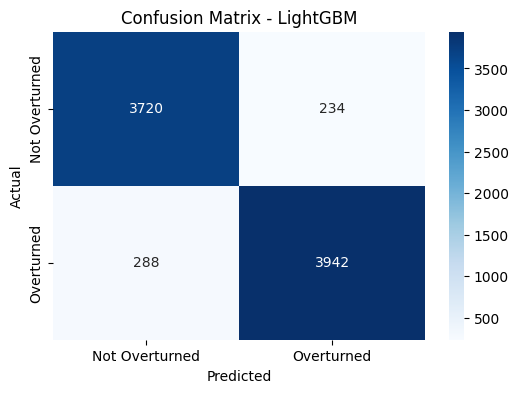

In [ ]:
# Confusion matrix for best model
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Overturned", "Overturned"],
    yticklabels=["Not Overturned", "Overturned"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

In [ ]:
example